In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

df=pd.read_csv('diamonds.csv')

df=df.loc[df['x']>=0.1] # the same df without the X<0
df=df.loc[df['y']>=0.1] # the same df without the y<0
df=df.loc[df['z']>=0.1] # the same df without the z<0

df = pd.get_dummies(df, columns = ['cut', 'color', 'clarity'])
df = df[(np.abs(zscore(df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z']])) < 3).all(axis=1)]

model = IsolationForest(contamination=0.05)  # Adjust contamination level as needed
outliers = model.fit_predict(df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z']])
df = df[outliers == 1]  # Keep non-outliers

X = df.drop('price', axis=1).to_numpy()
y=df['price'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Configure and train the Gradient Boosting model
gb_model = GradientBoostingRegressor( n_estimators= 1000,     # Number of trees (more trees = better fit, but slower training)
        learning_rate= 0.1,     # How much each tree contributes to the final result
        max_depth= 6,           # Maximum depth of each tree (controls model complexity)
        min_samples_leaf= 9,    # Minimum number of data points in each leaf (prevents overfitting)
        max_features= 0.1,      # Fraction of features to consider when splitting (adds randomness)
        loss="huber",           # Loss function that is robust to outliers
        random_state= 7         # Seed for reproducibility (same results every time)
        )
gb_model.fit(X_train, y_train)

y_pred= gb_model.predict(X_test) # predict on x-test

print(f"Random Forest MSE: {mean_squared_error(y_test, y_pred)}")
print(f"Random Forest MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"Random Forest R-squared: {r2_score(y_test, y_pred)}")
print(f"Random Forest Explained Variance Score: {explained_variance_score(y_test, y_pred)}")


c:\Users\Rohith\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Random Forest MSE: 145354.98366700544
Random Forest MAE: 212.9440427031855
Random Forest R-squared: 0.9839042796550033
Random Forest Explained Variance Score: 0.9839044905588372


In [21]:
import pandas as pd
import numpy as np

df=pd.read_csv('diamonds.csv')
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
49995,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
49996,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
49997,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
49998,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [22]:
df.describe()

,carat,depth,table,price,x,y,z
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,0.799444,61.753006,57.457830,3944.805440,5.734403,5.737956,3.541056
std,0.475173,1.431088,2.232092,3997.938105,1.123077,1.145579,0.707065
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2410.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5351.000000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [23]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [24]:
print(df.nunique())

carat        272
cut            5
color          7
clarity        8
depth        181
table        126
price      11297
x            553
y            551
z            371
dtype: int64


In [25]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [26]:
df=df.loc[df['x']>=0.1] # the same df without the X<0
df=df.loc[df['y']>=0.1] # the same df without the y<0
df=df.loc[df['z']>=0.1] # the same df without the z<0

In [27]:
df.describe()

,carat,depth,table,price,x,y,z
count,49983.000000,49983.000000,49983.000000,49983.000000,49983.000000,49983.000000,49983.000000
mean,0.799214,61.753088,57.457566,3943.076086,5.734869,5.738302,3.542260
std,0.474970,1.430864,2.231614,3995.956857,1.120889,1.143739,0.704162
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.400000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2409.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5347.000000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [28]:
df = pd.get_dummies(df, columns = ['cut', 'color', 'clarity'])


In [29]:
df.describe()

,carat,depth,table,price,x,y,z
count,49983.000000,49983.000000,49983.000000,49983.000000,49983.000000,49983.000000,49983.000000
mean,0.799214,61.753088,57.457566,3943.076086,5.734869,5.738302,3.542260
std,0.474970,1.430864,2.231614,3995.956857,1.120889,1.143739,0.704162
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.400000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2409.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5347.000000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [30]:
# use Z-score to remove extreme outliers for all numerical features.

from scipy.stats import zscore
df = df[(np.abs(zscore(df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z']])) < 3).all(axis=1)]
df

,carat,depth,table,price,x,y,z,cut_Fair,cut_Good,cut_Ideal,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,False,False,True,...,False,False,False,False,False,True,False,False,False,False
1,0.21,59.8,61.0,326,3.89,3.84,2.31,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,0.29,62.4,58.0,334,4.20,4.23,2.63,False,False,False,...,True,False,False,False,False,False,False,True,False,False
4,0.31,63.3,58.0,335,4.34,4.35,2.75,False,True,False,...,False,True,False,False,False,True,False,False,False,False
5,0.24,62.8,57.0,336,3.94,3.96,2.48,False,False,False,...,False,True,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0.72,60.8,57.0,2757,5.75,5.76,3.50,False,False,True,...,False,False,False,False,True,False,False,False,False,False
49996,0.72,63.1,55.0,2757,5.69,5.75,3.61,False,True,False,...,False,False,False,False,True,False,False,False,False,False
49997,0.70,62.8,60.0,2757,5.66,5.68,3.56,False,False,False,...,False,False,False,False,True,False,False,False,False,False
49998,0.86,61.0,58.0,2757,6.15,6.12,3.74,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [15]:
df.describe()

,carat,depth,table,price,x,y,z
count,47858.000000,47858.000000,47858.000000,47858.000000,47858.000000,47858.000000,47858.000000
mean,0.762144,61.755817,57.371401,3604.381796,5.662513,5.665964,3.497718
std,0.427162,1.271606,2.098628,3457.652426,1.060187,1.053058,0.654835
min,0.200000,57.500000,51.000000,326.000000,3.730000,3.680000,1.530000
25%,0.390000,61.100000,56.000000,928.000000,4.690000,4.700000,2.890000
50%,0.700000,61.800000,57.000000,2313.000000,5.660000,5.670000,3.500000
75%,1.020000,62.500000,59.000000,5068.000000,6.490000,6.490000,4.010000
max,2.220000,66.000000,64.000000,15930.000000,8.600000,8.570000,5.300000


<Axes: >

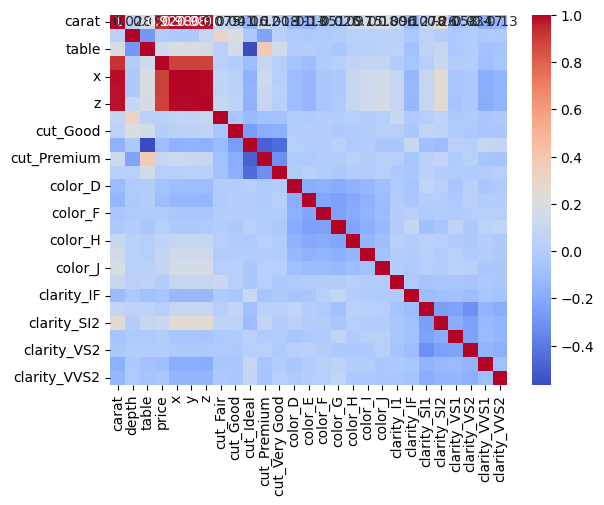

In [16]:
import pandas as pd  # For data manipulation (if you're working with a DataFrame)
import seaborn as sns  # For the heatmap
import matplotlib.pyplot as plt  # For displaying the heatmap

correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')


In [17]:
from sklearn.ensemble import IsolationForest
model = IsolationForest(contamination=0.05)  # Adjust contamination level as needed
outliers = model.fit_predict(df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z']])
df = df[outliers == 1]  # Keep non-outliers


c:\Users\Rohith\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


In [18]:
df.describe()

,carat,depth,table,price,x,y,z
count,45465.000000,45465.000000,45465.000000,45465.000000,45465.000000,45465.000000,45465.000000
mean,0.718547,61.758311,57.322426,3252.671484,5.578779,5.583286,3.446554
std,0.366848,1.227968,2.063405,2973.303146,0.969846,0.964438,0.599801
min,0.230000,57.500000,51.000000,326.000000,3.900000,3.940000,2.250000
25%,0.390000,61.100000,56.000000,912.000000,4.670000,4.690000,2.880000
50%,0.700000,61.800000,57.000000,2167.000000,5.590000,5.580000,3.440000
75%,1.010000,62.500000,59.000000,4704.000000,6.430000,6.430000,3.980000
max,1.720000,66.000000,64.000000,15928.000000,7.740000,7.720000,5.060000


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

X = df.drop('price', axis=1).to_numpy()
y=df['price'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

LR_model = LinearRegression()
LR_model.fit(X_train, y_train)

# Predict and evaluate
y_LR_pred = LR_model.predict(X_test)

print(f"Linear Regression MSE: {mean_squared_error(y_test, y_LR_pred)}")
print(f"Linear Regression MAE: {mean_absolute_error(y_test, y_LR_pred)}")
print(f"Linear Regression R-squared: {r2_score(y_test, y_LR_pred)}")
print(f"Linear Regression Explained Variance Score: {explained_variance_score(y_test, y_LR_pred)}")

# Configure and train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_rf_pred = rf_model.predict(X_test)

print(f"Random Forest MSE: {mean_squared_error(y_test, y_rf_pred)}")
print(f"Random Forest MAE: {mean_absolute_error(y_test, y_rf_pred)}")
print(f"Random Forest R-squared: {r2_score(y_test, y_rf_pred)}")
print(f"Random Forest Explained Variance Score: {explained_variance_score(y_test, y_rf_pred)}")

# Configure and train the Gradient Boosting model
gb_model = GradientBoostingRegressor( n_estimators= 1000,     # Number of trees (more trees = better fit, but slower training)
        learning_rate= 0.1,     # How much each tree contributes to the final result
        max_depth= 6,           # Maximum depth of each tree (controls model complexity)
        min_samples_leaf= 9,    # Minimum number of data points in each leaf (prevents overfitting)
        max_features= 0.1,      # Fraction of features to consider when splitting (adds randomness)
        loss="huber",           # Loss function that is robust to outliers
        random_state= 7         # Seed for reproducibility (same results every time)
        )
gb_model.fit(X_train, y_train)

# Predict and evaluate
y_gb_pred = gb_model.predict(X_test)

print(f"Gradient Boosting MSE: {mean_squared_error(y_test, y_gb_pred)}")
print(f"Gradient Boosting MAE: {mean_absolute_error(y_test, y_gb_pred)}")
print(f"Gradient Boosting R-squared: {r2_score(y_test, y_gb_pred)}")
print(f"Gradient Boosting Explained Variance Score: {explained_variance_score(y_test, y_gb_pred)}")

# Configure and train the Decision Tree model
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

# Predict and evaluate
y_dt_pred = dt_model.predict(X_test)

print(f"Decision Tree MSE: {mean_squared_error(y_test, y_dt_pred)}")
print(f"Decision Tree MAE: {mean_absolute_error(y_test, y_dt_pred)}")
print(f"Decision Tree R-squared: {r2_score(y_test, y_dt_pred)}")
print(f"Decision Tree Explained Variance Score: {explained_variance_score(y_test, y_dt_pred)}")

# Configure and train the KNN model
knn_model = KNeighborsRegressor(n_neighbors=5, weights='distance')
knn_model.fit(X_train, y_train)

# Predict and evaluate
y_knn_pred = knn_model.predict(X_test)

print(f"KNN MSE: {mean_squared_error(y_test, y_knn_pred)}")
print(f"KNN MAE: {mean_absolute_error(y_test, y_knn_pred)}")
print(f"KNN R-squared: {r2_score(y_test, y_knn_pred)}")
print(f"KNN Explained Variance Score: {explained_variance_score(y_test, y_knn_pred)}")

# # Configure and train the SVR model
# svr_model = SVR(kernel='rbf', C=100, gamma=0.1)
# svr_model.fit(X_train, y_train)

# # Predict and evaluate
# y_svr_pred = svr_model.predict(X_test)
# svr_mse = mean_squared_error(y_test, y_svr_pred)
# svr_mae = mean_absolute_error(y_test, y_svr_pred)

# print(f"SVR MSE: {svr_mse}")
# print(f"SVR MAE: {svr_mae}")

Linear Regression MSE: 712826.6081093433
Linear Regression MAE: 570.4645794269704
Linear Regression R-squared: 0.9181666004167254
Linear Regression Explained Variance Score: 0.9181732904285743
Random Forest MSE: 242809.12869702373
Random Forest MAE: 281.359619520627
Random Forest R-squared: 0.9721252037661277
Random Forest Explained Variance Score: 0.9721266083906956
Gradient Boosting MSE: 142155.319137188
Gradient Boosting MAE: 213.3108519842926
Gradient Boosting R-squared: 0.9836803888891069
Gradient Boosting Explained Variance Score: 0.9836847037600913
Decision Tree MSE: 314533.4282684432
Decision Tree MAE: 318.941590519255
Decision Tree R-squared: 0.963891163117412
Decision Tree Explained Variance Score: 0.9638917146480948
KNN MSE: 427790.5734900903
KNN MAE: 373.6153096629134
KNN R-squared: 0.9508890990598337
KNN Explained Variance Score: 0.9510648397570578


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

X = df.drop('price', axis=1).to_numpy()
y=df['price'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Configure and train the Gradient Boosting model
gb_model = GradientBoostingRegressor( n_estimators= 1000,     # Number of trees (more trees = better fit, but slower training)
        learning_rate= 0.1,     # How much each tree contributes to the final result
        max_depth= 6,           # Maximum depth of each tree (controls model complexity)
        min_samples_leaf= 9,    # Minimum number of data points in each leaf (prevents overfitting)
        max_features= 0.1,      # Fraction of features to consider when splitting (adds randomness)
        loss="huber",           # Loss function that is robust to outliers
        random_state= 7         # Seed for reproducibility (same results every time)
        )
gb_model.fit(X_train, y_train)

# Predict and evaluate
y_gb_pred = gb_model.predict(X_test)

print(f"Gradient Boosting MSE: {mean_squared_error(y_test, y_gb_pred)}")
print(f"Gradient Boosting MAE: {mean_absolute_error(y_test, y_gb_pred)}")
print(f"Gradient Boosting R-squared: {r2_score(y_test, y_gb_pred)}")
print(f"Gradient Boosting Explained Variance Score: {explained_variance_score(y_test, y_gb_pred)}")


Gradient Boosting MSE: 200325.9281924021
Gradient Boosting MAE: 244.40242820378936
Gradient Boosting R-squared: 0.9832257455962798
Gradient Boosting Explained Variance Score: 0.9832284223978097


In [32]:
importance = model.feature_importances_
feature_index_by_importance = importance.argsort()
feature_index_by_importance

AttributeError: 'IsolationForest' object has no attribute 'feature_importances_'